# Оценка кредитного риска


- `credit_risk = 0` — плохой кредит;
- `credit_risk = 1` — хороший кредит.

## Цель работы

Построить модель, которая снижает количество кредитов, выданных плохим клиентам, и одновременно контролирует количество необоснованных отказов хорошим клиентам.



## Область работы 1 — библиотеки и настройки

In [1]:

from pathlib import Path
import json
import warnings
import seaborn as sns

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler, FunctionTransformer
from sklearn.impute import SimpleImputer

from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import (
    RandomForestClassifier,
    ExtraTreesClassifier,
    GradientBoostingClassifier,
)

from sklearn.model_selection import (
    StratifiedKFold,
    GridSearchCV,
    cross_val_predict,
)

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
)
from sklearn.inspection import permutation_importance

warnings.filterwarnings('ignore')

RANDOM_STATE = 42
BAD_LABEL = 0
GOOD_LABEL = 1
TARGET = 'credit_risk'

BAD_APPROVAL_COST = 2
GOOD_REJECTION_COST = 1

## Область работы 2 — EDA, сравнение и выбор модели


### 1. Загрузка обучающих данных

In [2]:

path_train = Path('train_3dz.csv')

if not path_train.exists():
    raise FileNotFoundError(
        'Файл train_3dz.csv не найден. Поместите его в одну папку с ноутбуком.'
    )

train_df = pd.read_csv(path_train)

print(f'Размер train: {train_df.shape}')
display(train_df.head())

Размер train: (750, 21)


,status,duration,credit_history,purpose,amount,savings,employment_duration,installment_rate,personal_status_sex,other_debtors,...,property,age,other_installment_plans,housing,number_credits,job,people_liable,telephone,foreign_worker,credit_risk
0,2,18,2,6,1239,5,3,4,3,1,...,4,61,3,3,1,3,2,1,2,1
1,1,30,0,9,8072,5,2,2,3,1,...,3,25,1,2,3,3,2,1,2,1
2,4,27,3,1,8613,4,3,2,3,1,...,3,27,3,2,2,3,2,1,2,1
3,4,9,2,4,1236,1,2,1,2,1,...,1,23,3,1,1,3,2,2,2,1
4,1,6,4,0,4716,5,2,1,3,1,...,1,44,3,2,2,2,1,1,2,1


### 2. Описание признаков

Числовые коды категорий соответствуют категориям из условия. В моделях они не рассматриваются как обычные непрерывные числа: все дискретные признаки кодируются через One-Hot Encoding.

In [3]:
feature_description = pd.DataFrame({
    'feature': [
        'status', 'duration', 'credit_history', 'purpose', 'amount', 'savings',
        'employment_duration', 'installment_rate', 'personal_status_sex',
        'other_debtors', 'present_residence', 'property', 'age',
        'other_installment_plans', 'housing', 'number_credits', 'job',
        'people_liable', 'telephone', 'foreign_worker', 'credit_risk'
    ],
    'description': [
        'Состояние текущего счёта',
        'Срок кредита',
        'Кредитная история',
        'Цель кредита',
        'Сумма кредита',
        'Сбережения',
        'Продолжительность текущей занятости',
        'Доля платежа в располагаемом доходе',
        'Семейный статус и пол',
        'Созаявитель или поручитель',
        'Продолжительность проживания по текущему адресу',
        'Имущество',
        'Возраст',
        'Другие кредитные планы',
        'Тип жилья',
        'Количество кредитов',
        'Тип занятости',
        'Количество иждивенцев',
        'Наличие телефона',
        'Иностранный работник',
        '0 — плохой кредит, 1 — хороший кредит'
    ],
    'model_type': [
        'categorical', 'numeric', 'categorical', 'categorical', 'numeric',
        'categorical', 'categorical', 'categorical', 'categorical', 'categorical',
        'categorical', 'categorical', 'numeric', 'categorical', 'categorical',
        'categorical', 'categorical', 'categorical', 'categorical', 'categorical',
        'target'
    ]
})

display(feature_description)

,feature,description,model_type
0,status,Состояние текущего счёта,categorical
1,duration,Срок кредита,numeric
2,credit_history,Кредитная история,categorical
3,purpose,Цель кредита,categorical
4,amount,Сумма кредита,numeric
5,savings,Сбережения,categorical
6,employment_duration,Продолжительность текущей занятости,categorical
7,installment_rate,Доля платежа в располагаемом доходе,categorical
8,personal_status_sex,Семейный статус и пол,categorical
9,other_debtors,Созаявитель или поручитель,categorical


### 3. Проверка структуры и качества данных

In [40]:
if TARGET not in train_df.columns:
    raise ValueError(f'В train отсутствует целевая колонка {TARGET!r}.')

expected_target_values = {BAD_LABEL, GOOD_LABEL}
actual_target_values = set(train_df[TARGET].dropna().unique())
if actual_target_values != expected_target_values:
    raise ValueError(
        f'Ожидались значения target {expected_target_values}, получены {actual_target_values}.'
    )

quality_table = pd.DataFrame({
    'dtype': train_df.dtypes.astype(str),
    'missing': train_df.isna().sum(),
    'missing_%': (train_df.isna().mean() * 100).round(2),
    'n_unique': train_df.nunique(dropna=False),
})

print(f'Количество полных дубликатов: {train_df.duplicated().sum()}')
print(f'Количество пропусков во всём наборе: {train_df.isna().sum().sum()}')
display(quality_table)

Количество полных дубликатов: 0
Количество пропусков во всём наборе: 0


,dtype,missing,missing_%,n_unique
status,int64,0,0.0,4
duration,int64,0,0.0,31
credit_history,int64,0,0.0,5
purpose,int64,0,0.0,10
amount,int64,0,0.0,706
savings,int64,0,0.0,5
employment_duration,int64,0,0.0,5
installment_rate,int64,0,0.0,4
personal_status_sex,int64,0,0.0,4
other_debtors,int64,0,0.0,3


### 4. Распределение целевой переменной

,class_name,count,share_%
0,bad,225,30.0
1,good,525,70.0


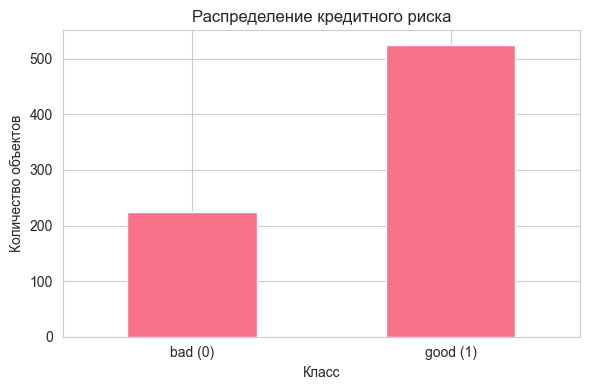

In [41]:
target_counts = train_df[TARGET].value_counts().sort_index()
target_share = (train_df[TARGET].value_counts(normalize=True).sort_index() * 100).round(2)

target_table = pd.DataFrame({
    'class_name': ['bad', 'good'],
    'count': [target_counts.loc[0], target_counts.loc[1]],
    'share_%': [target_share.loc[0], target_share.loc[1]],
}, index=[0, 1])

display(target_table)

plt.figure(figsize=(6, 4))
target_counts.rename(index={0: 'bad (0)', 1: 'good (1)'}).plot(kind='bar')
plt.title('Распределение кредитного риска')
plt.xlabel('Класс')
plt.ylabel('Количество объектов')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

Выборка умеренно несбалансирована: хороших кредитов больше. Поэтому одной accuracy недостаточно. В дальнейшем отдельно оцениваются обнаружение плохих кредитов, ошибочно одобренные плохие кредиты и отклонённые хорошие кредиты.

### 5. Анализ числовых признаков

In [5]:
numeric_features = ['duration', 'amount', 'age']
categorical_features = [
    column for column in train_df.columns
    if column not in numeric_features + [TARGET]
]

numeric_summary = train_df[numeric_features].describe().T
numeric_summary['median'] = train_df[numeric_features].median()
numeric_summary['skewness'] = train_df[numeric_features].skew()
display(numeric_summary)

numeric_by_target = train_df.groupby(TARGET)[numeric_features].agg(['mean', 'median', 'std'])
display(numeric_by_target)

,count,mean,std,min,25%,50%,75%,max,median,skewness
duration,750.0,21.058667,12.152866,4.0,12.00,18.0,24.00,72.0,18.0,1.097442
amount,750.0,3315.892000,2887.629212,250.0,1373.25,2330.0,3975.25,18424.0,2330.0,2.002593
age,750.0,35.305333,11.230150,19.0,27.00,33.0,42.00,75.0,33.0,1.019662


duration                         amount                       \
                  mean median        std         mean  median          std   
credit_risk                                                                  
0            24.724444   24.0  13.301604  4081.275556  2625.0  3734.587398   
1            19.487619   18.0  11.279683  2987.870476  2299.0  2365.870036   

                   age                    
                  mean median        std  
credit_risk                               
0            33.817778   30.0  11.425131  
1            35.942857   34.0  11.095550

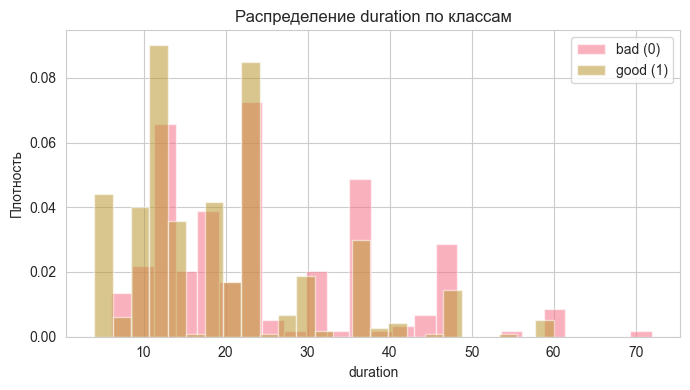

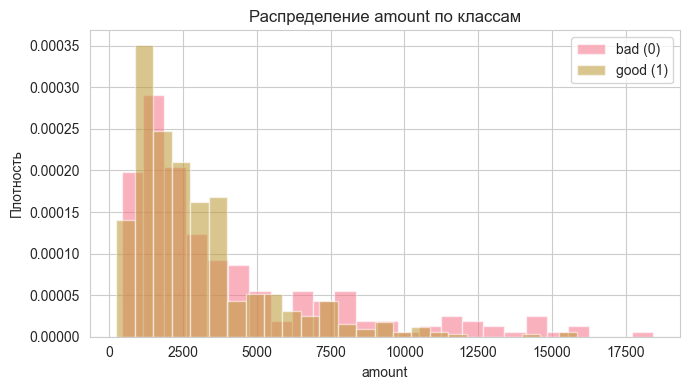

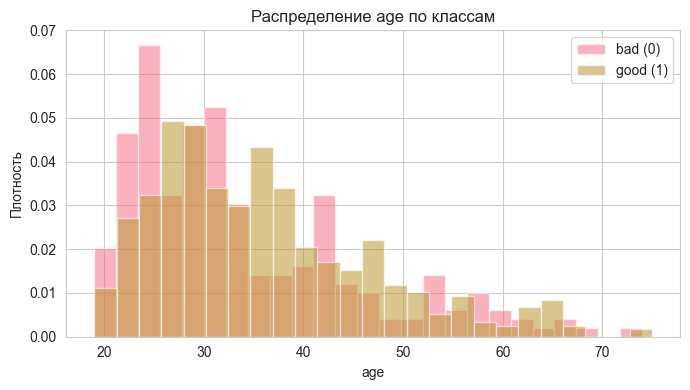

In [43]:
for feature in numeric_features:
    plt.figure(figsize=(7, 4))
    train_df.loc[train_df[TARGET] == BAD_LABEL, feature].plot(
        kind='hist', bins=25, alpha=0.55, density=True, label='bad (0)'
    )
    train_df.loc[train_df[TARGET] == GOOD_LABEL, feature].plot(
        kind='hist', bins=25, alpha=0.55, density=True, label='good (1)'
    )
    plt.title(f'Распределение {feature} по классам')
    plt.xlabel(feature)
    plt.ylabel('Плотность')
    plt.legend()
    plt.tight_layout()
    plt.show()

Краткий вывод: Плохие клиенты отличаются смещёнными вправо распределениями и длинными хвостами по сроку и сумме кредита. Возраст не даёт чёткого разделения классов, так как его распределения почти полностью перекрываются. Для amount можно попробовать логарифмирование  для коррекции сильной асимметрии.

<Figure size 600x400 with 0 Axes>

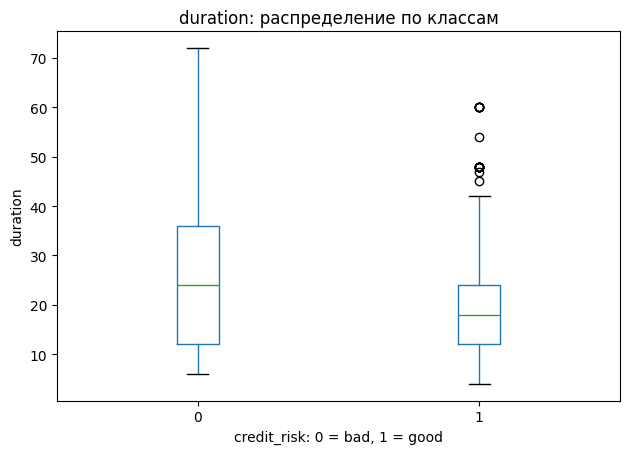

<Figure size 600x400 with 0 Axes>

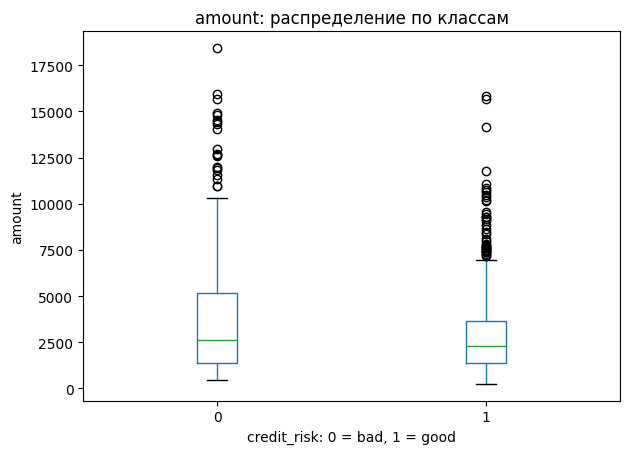

<Figure size 600x400 with 0 Axes>

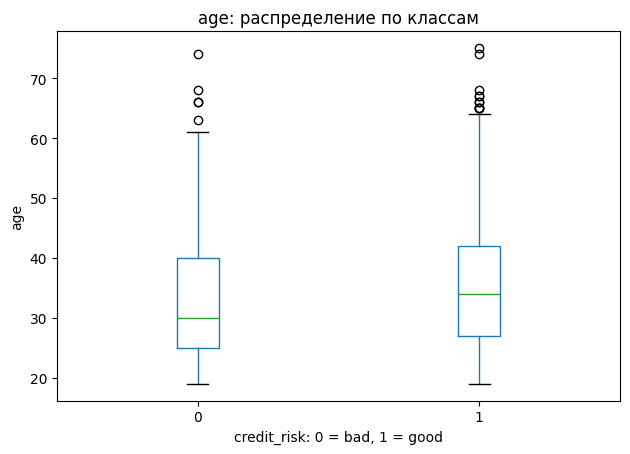

In [6]:
for feature in numeric_features:
    plt.figure(figsize=(6, 4))
    train_df.boxplot(column=feature, by=TARGET, grid=False)
    plt.title(f'{feature}: распределение по классам')
    plt.suptitle('')
    plt.xlabel('credit_risk: 0 = bad, 1 = good')
    plt.ylabel(feature)
    plt.tight_layout()
    plt.show()

Краткий вывод: Плохие клиенты имеют более высокие медианы и больший разброс значений по сроку и сумме кредита. У них заметно больше экстремальных выбросов — очень долгих и очень крупных кредитов. По возрасту различия минимальны, что подтверждает его второстепенную роль.


In [45]:
def iqr_outlier_summary(data, columns):
    rows = []
    for column in columns:
        q1 = data[column].quantile(0.25)
        q3 = data[column].quantile(0.75)
        iqr = q3 - q1
        lower = q1 - 1.5 * iqr
        upper = q3 + 1.5 * iqr
        n_outliers = ((data[column] < lower) | (data[column] > upper)).sum()
        rows.append({
            'feature': column,
            'q1': q1,
            'q3': q3,
            'lower_iqr_bound': lower,
            'upper_iqr_bound': upper,
            'outlier_count': int(n_outliers),
            'outlier_share_%': round(n_outliers / len(data) * 100, 2),
        })
    return pd.DataFrame(rows)

outlier_table = iqr_outlier_summary(train_df, numeric_features)
log_comparison = pd.DataFrame({
    'feature': ['amount'],
    'skew_original': [train_df['amount'].skew()],
    'skew_log1p': [np.log1p(train_df['amount']).skew()],
})

display(outlier_table)
display(log_comparison)

,feature,q1,q3,lower_iqr_bound,upper_iqr_bound,outlier_count,outlier_share_%
0,duration,12.00,24.00,-6.00,42.00,53,7.07
1,amount,1373.25,3975.25,-2529.75,7878.25,56,7.47
2,age,27.00,42.00,4.50,64.50,15,2.00


,feature,skew_original,skew_log1p
0,amount,2.002593,0.100157


Большие значения `amount` и `duration` не удаляются автоматически: они могут быть реальными кредитными заявками и содержать полезный сигнал. Для `amount` в линейной модели применяется `log1p`, уменьшающий правую асимметрию.

### 6. Анализ категориальных признаков

In [46]:
def categorical_target_summary(data, columns, target):
    all_rows = []
    feature_rows = []

    for column in columns:
        grouped = (
            data.groupby(column, dropna=False)[target]
            .agg(count='size', good_rate='mean')
            .reset_index()
        )
        grouped['bad_rate'] = 1 - grouped['good_rate']
        grouped['feature'] = column
        grouped['share_%'] = grouped['count'] / len(data) * 100
        all_rows.append(grouped)

        sufficiently_large = grouped[grouped['count'] >= 10]
        if sufficiently_large.empty:
            bad_rate_range = np.nan
        else:
            bad_rate_range = (
                sufficiently_large['bad_rate'].max()
                - sufficiently_large['bad_rate'].min()
            )

        feature_rows.append({
            'feature': column,
            'n_categories': grouped.shape[0],
            'min_category_count': int(grouped['count'].min()),
            'max_bad_rate_difference': bad_rate_range,
        })

    category_table = pd.concat(all_rows, ignore_index=True)
    feature_table = pd.DataFrame(feature_rows).sort_values(
        'max_bad_rate_difference', ascending=False
    )
    return category_table, feature_table

category_table, categorical_strength = categorical_target_summary(
    train_df, categorical_features, TARGET
)

display(categorical_strength)
#display(category_table.sort_values(['feature', 'bad_rate'], ascending=[True, False]))

,feature,n_categories,min_category_count,max_bad_rate_difference
1,credit_history,5,34,0.462396
0,status,4,46,0.397887
2,purpose,10,7,0.287879
3,savings,5,38,0.258373
7,other_debtors,3,31,0.192082
9,property,4,114,0.188556
16,foreign_worker,2,27,0.157523
11,housing,3,79,0.156236
10,other_installment_plans,3,36,0.140351
12,number_credits,4,6,0.135795


Функция оценивает силу категориальных признаков по разбросу доли плохих клиентов между категориями.  

Сильнейшие: credit_history и status (разрыв 40-46%).  
Слабейшие: telephone и people_liable (разрыв < 2%).

### Графики доли плохих кредитов по категориям (топ-8 сильнейших признаков)

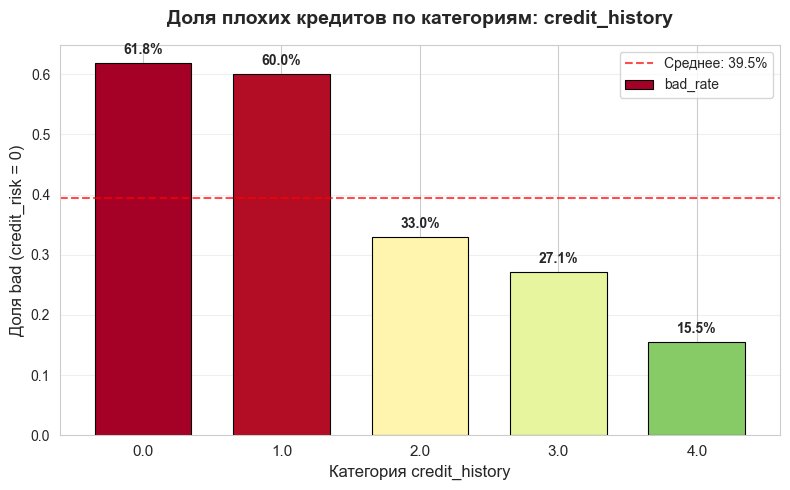

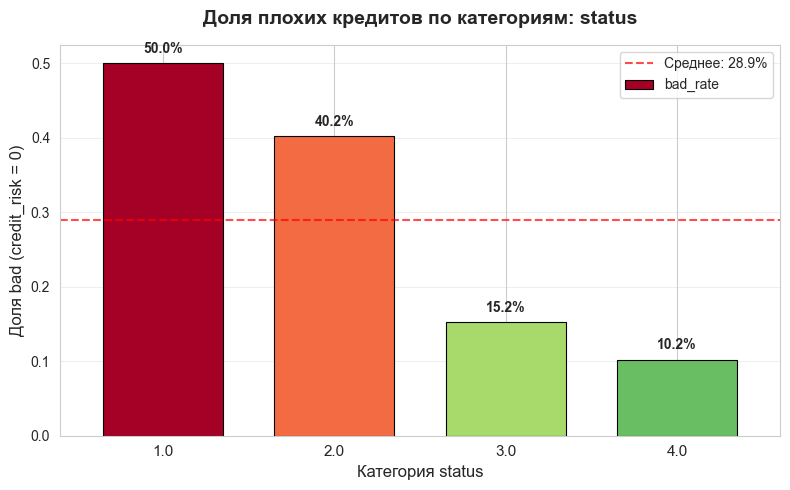

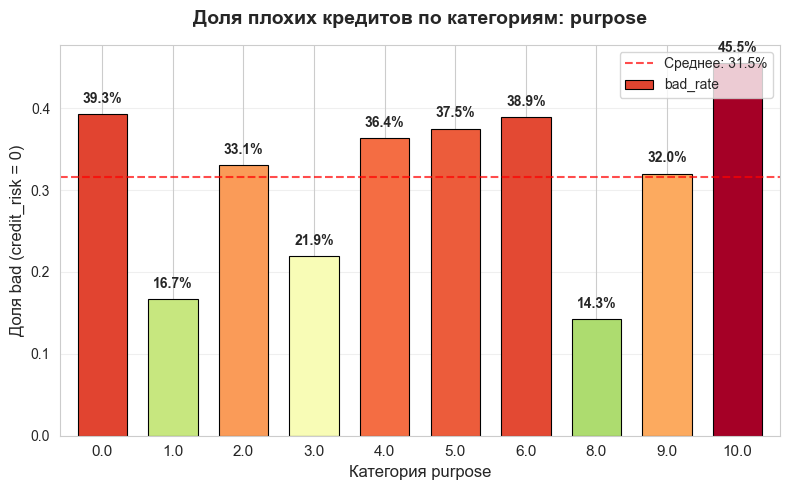

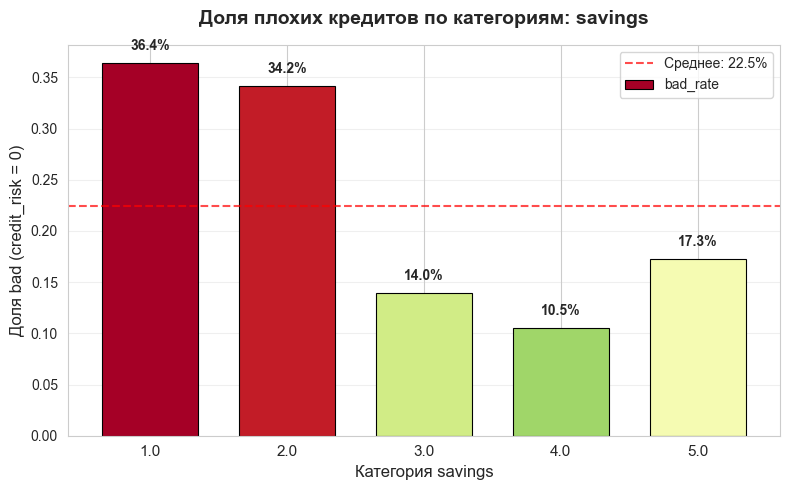

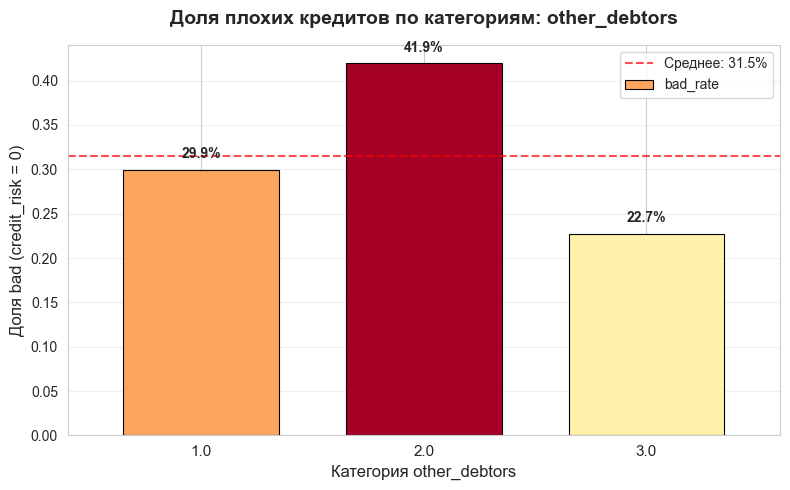

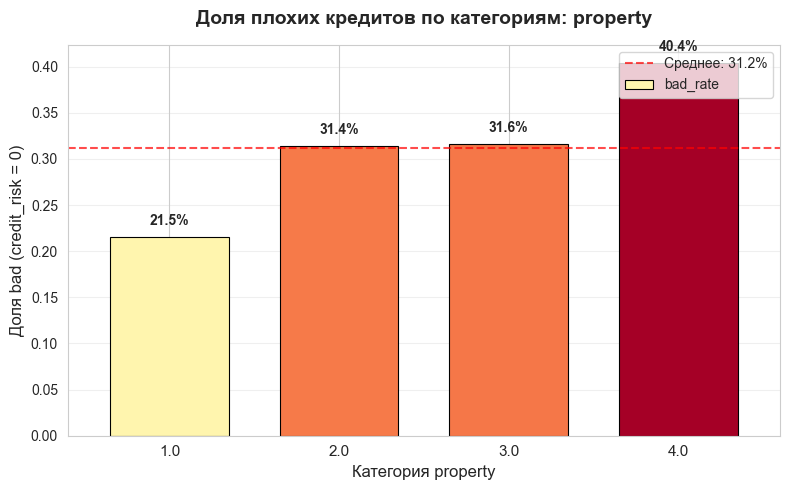

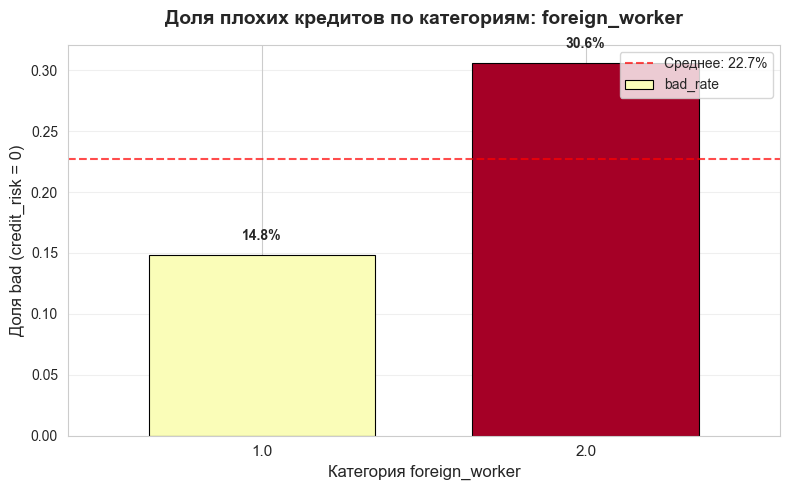

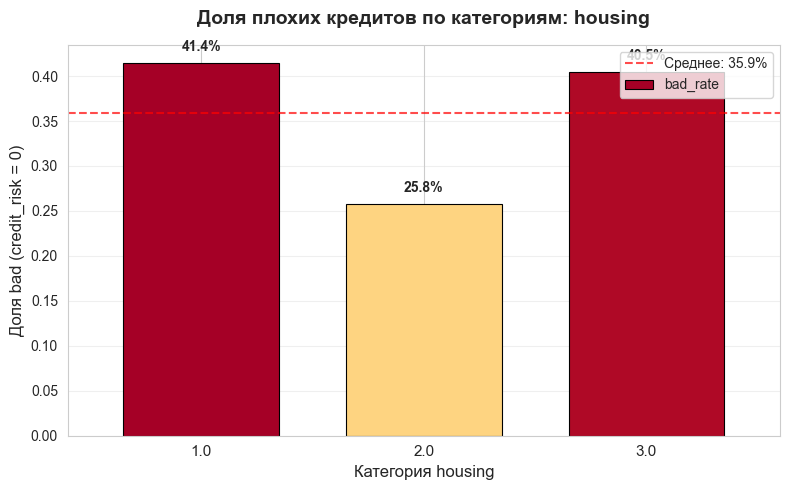

In [47]:

sns.set_style("whitegrid")
sns.set_palette("husl")

# Графики доли плохих кредитов по категориям (топ-8 сильнейших признаков)
top_categorical_features = categorical_strength.head(8)['feature'].tolist()

for feature in top_categorical_features:
    plot_data = (
        category_table[category_table['feature'] == feature]
        .sort_values(feature)
        .set_index(feature)
    )
    
    colors = plt.cm.RdYlGn_r(plot_data['bad_rate'] / plot_data['bad_rate'].max())
    
    plt.figure(figsize=(8, 5))
    
    ax = plot_data['bad_rate'].plot(
        kind='bar',
        color=colors,
        edgecolor='black',
        linewidth=0.8,
        width=0.7
    )
    
    plt.title(
        f'Доля плохих кредитов по категориям: {feature}',
        fontsize=14,
        fontweight='bold',
        pad=15
    )
    plt.xlabel(f'Категория {feature}', fontsize=12)
    plt.ylabel('Доля bad (credit_risk = 0)', fontsize=12)
    plt.xticks(rotation=0, fontsize=11)
    
    for i, (idx, row) in enumerate(plot_data.iterrows()):
        ax.text(
            i,
            row['bad_rate'] + 0.01,
            f"{row['bad_rate']:.1%}",
            ha='center',
            va='bottom',
            fontsize=10,
            fontweight='bold'
        )
    
    mean_bad = plot_data['bad_rate'].mean()
    ax.axhline(
        y=mean_bad,
        color='red',
        linestyle='--',
        linewidth=1.5,
        alpha=0.7,
        label=f'Среднее: {mean_bad:.1%}'
    )
    
    plt.legend(loc='upper right', fontsize=10)
    plt.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()

Категориальные признаки имеют ограниченное количество значений, поэтому One-Hot Encoding не создаёт чрезмерно широкую матрицу. Редкие категории не удаляются и не объединяются без проверки: `handle_unknown='ignore'` достаточно для безопасного применения модели к внешнему test.

### 7. Корреляции числовых признаков

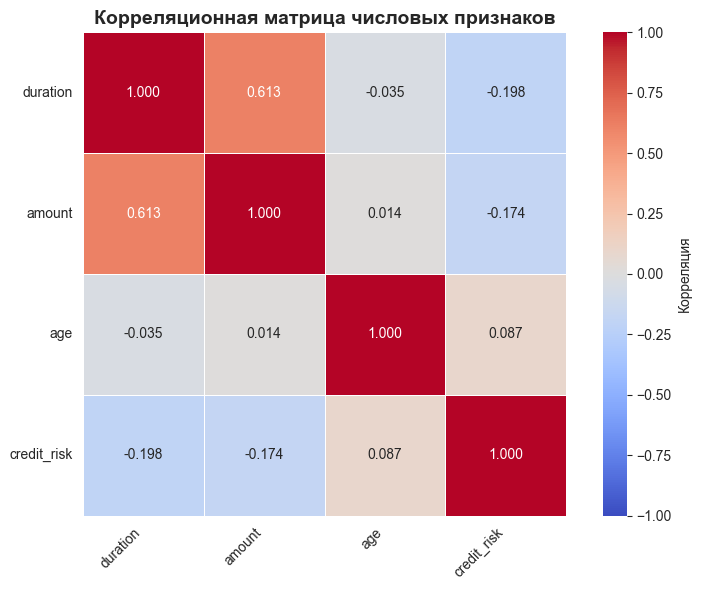

In [48]:
import seaborn as sns

# Данные для корреляции
corr_columns = numeric_features + [TARGET]
correlation_matrix = train_df[corr_columns].corr()

# Настройка размера и стиля
plt.figure(figsize=(8, 6))

# Тепловая карта
sns.heatmap(
    correlation_matrix,
    annot=True,           # Показывать цифры внутри ячеек
    fmt='.3f',            # Формат чисел (3 знака после запятой)
    cmap='coolwarm',      # Цветовая схема: синий-белый-красный
    center=0,             # Центр цветовой шкалы (0)
    square=True,          # Квадратные ячейки
    linewidths=0.5,       # Тонкие линии между ячейками
    cbar_kws={'label': 'Корреляция'},  # Подпись для шкалы
    annot_kws={'size': 10},            # Размер цифр
    vmin=-1, vmax=1       # Диапазон корреляции
)

plt.title('Корреляционная матрица числовых признаков', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

Срок и сумма кредита умеренно коррелируют с риском дефолта (отрицательная связь) и сильно связаны друг с другом (0.61). Возраст практически не коррелирует ни с одним признаком. Мультиколлинеарность между сроком и суммой присутствует, но не критична для выбранных ансамблевых моделей.



### 8. Краткие выводы EDA
- Выборка чистая: 750 строк, пропуски и дубликаты отсутствуют.

- Целевая переменная сбалансирована умеренно: 30% плохих кредитов.

- Ключевые признаки риска — duration и amount. У них сильная правосторонняя асимметрия, особенно у amount, что требует логарифмирования.

- duration и amount коррелируют между собой (0.61), но с целевой переменной связь умеренная отрицательная (-0.20 и -0.17).

- age — слабый признак, значимых зависимостей не показывает.

- Сильнейшие категориальные признаки — credit_history и status (разрыв между категориями 40–46% по доле плохих).

- Слабые категориальные признаки — telephone, people_liable, foreign_worker (разрыв менее 3%).

### 9. Подготовка признаков

In [49]:
X = train_df.drop(columns=TARGET)
y = train_df[TARGET].copy()

regular_numeric_features = ['duration', 'age']
amount_feature = ['amount']

regular_numeric_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
])

amount_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('log1p', FunctionTransformer(np.log1p, feature_names_out='one-to-one')),
    ('scaler', StandardScaler()),
])

categorical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore')),
])

preprocessor = ColumnTransformer([
    ('numeric', regular_numeric_pipeline, regular_numeric_features),
    ('amount', amount_pipeline, amount_feature),
    ('categorical', categorical_pipeline, categorical_features),
])

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE,
)



### 10. Метрики и бизнес-интерпретация ошибок

**Метрики качества модели**  
accuracy – доля правильных ответов модели (всех верных предсказаний ко всем предсказаниям).

balanced_accuracy – средняя точность по каждому классу отдельно, используется при дисбалансе классов.

precision_bad – точность модели по классу "плохой": доля реально плохих среди тех, кого модель отнесла к плохим.

recall_bad – полнота по классу "плохой": доля плохих, которых модель смогла обнаружить.

f1_bad – среднее гармоническое между precision_bad и recall_bad, баланс между ними.

roc_auc_bad – способность модели разделять классы по вероятностям (от 0.5 — случайно, до 1.0 — идеально).

pr_auc_bad – площадь под кривой precision-recall, более честная метрика при дисбалансе классов.

**Бизнес-метрики ошибок**  
bad_approved – количество плохих клиентов, которым банк ошибочно одобрил кредит.

good_rejected – количество хороших клиентов, которым банк ошибочно отказал.

total_errors – общее количество ошибок модели.

equal_error_rate – доля ошибочных решений от всех заявок.

business_cost_per_100 – взвешенная стоимость ошибок в расчёте на 100 заявок с учётом весов bad_approval_cost и good_rejection_cost.

**Дополнительные бизнес-показатели**  
approval_rate – доля заявок, которые модель одобрила.

bad_rate_among_approved – доля плохих клиентов среди всех одобренных заявок.



In [50]:
def get_bad_probability(fitted_estimator, X_part):
    probabilities = fitted_estimator.predict_proba(X_part)
    classes = fitted_estimator.named_steps['model'].classes_
    bad_index = int(np.where(classes == BAD_LABEL)[0][0])
    return probabilities[:, bad_index]


def calculate_metrics(
    y_true,
    y_pred,
    probability_bad,
    bad_approval_cost=BAD_APPROVAL_COST,
    good_rejection_cost=GOOD_REJECTION_COST,
):
    cm = confusion_matrix(y_true, y_pred, labels=[BAD_LABEL, GOOD_LABEL])

    # Строки — фактический класс, столбцы — предсказанный.
    correctly_rejected_bad = int(cm[0, 0])
    bad_approved = int(cm[0, 1])       # standard FP for positive class 1
    good_rejected = int(cm[1, 0])      # standard FN for positive class 1
    correctly_approved_good = int(cm[1, 1])

    n = len(y_true)
    predicted_good = bad_approved + correctly_approved_good

    return {
        'accuracy': accuracy_score(y_true, y_pred),
        'balanced_accuracy': balanced_accuracy_score(y_true, y_pred),
        'precision_bad': precision_score(
            y_true, y_pred, pos_label=BAD_LABEL, zero_division=0
        ),
        'recall_bad': recall_score(
            y_true, y_pred, pos_label=BAD_LABEL, zero_division=0
        ),
        'f1_bad': f1_score(
            y_true, y_pred, pos_label=BAD_LABEL, zero_division=0
        ),
        'roc_auc_bad': roc_auc_score(
            (np.asarray(y_true) == BAD_LABEL).astype(int), probability_bad
        ),
        'pr_auc_bad': average_precision_score(
            (np.asarray(y_true) == BAD_LABEL).astype(int), probability_bad
        ),
        'correctly_rejected_bad': correctly_rejected_bad,
        'bad_approved': bad_approved,
        'good_rejected': good_rejected,
        'correctly_approved_good': correctly_approved_good,
        'total_errors': bad_approved + good_rejected,
        'equal_error_rate': (bad_approved + good_rejected) / n,
        'business_cost_per_100': (
            bad_approval_cost * bad_approved
            + good_rejection_cost * good_rejected
        ) / n * 100,
        'approval_rate': predicted_good / n,
        'bad_rate_among_approved': (
            bad_approved / predicted_good if predicted_good > 0 else np.nan
        ),
    }

### 11. Сравнение базовых моделей через одинаковую CV

In [51]:
def evaluate_model_cv(model_name, model, X_data, y_data, splitter):
    fold_rows = []

    for fold_number, (train_idx, valid_idx) in enumerate(
        splitter.split(X_data, y_data), start=1
    ):
        X_train_fold = X_data.iloc[train_idx]
        X_valid_fold = X_data.iloc[valid_idx]
        y_train_fold = y_data.iloc[train_idx]
        y_valid_fold = y_data.iloc[valid_idx]

        estimator = Pipeline([
            ('preprocessor', clone(preprocessor)),
            ('model', clone(model)),
        ])
        estimator.fit(X_train_fold, y_train_fold)

        prediction = estimator.predict(X_valid_fold)
        probability_bad = get_bad_probability(estimator, X_valid_fold)

        metrics = calculate_metrics(
            y_valid_fold,
            prediction,
            probability_bad,
        )
        metrics['model'] = model_name
        metrics['fold'] = fold_number
        fold_rows.append(metrics)

    return pd.DataFrame(fold_rows)


base_models = {
    'Dummy': DummyClassifier(strategy='most_frequent'),
    'LogisticRegression': LogisticRegression(
        max_iter=3000,
        random_state=RANDOM_STATE,
    ),
    'RandomForest': RandomForestClassifier(
        n_estimators=120,
        random_state=RANDOM_STATE,
        n_jobs=1,
    ),
    'ExtraTrees': ExtraTreesClassifier(
        n_estimators=120,
        random_state=RANDOM_STATE,
        n_jobs=1,
    ),
    'GradientBoosting': GradientBoostingClassifier(
        random_state=RANDOM_STATE,
    ),
}

base_fold_results = pd.concat([
    evaluate_model_cv(name, model, X, y, cv)
    for name, model in base_models.items()
], ignore_index=True)

metric_columns = [
    'accuracy', 'balanced_accuracy', 'precision_bad', 'recall_bad', 'f1_bad',
    'roc_auc_bad', 'pr_auc_bad', 'business_cost_per_100',
    'bad_approved', 'good_rejected',
]

base_summary = (
    base_fold_results
    .groupby('model')[metric_columns]
    .agg(['mean', 'std'])
)

base_ranking = (
    base_fold_results
    .groupby('model')[metric_columns]
    .mean()
    .sort_values(['business_cost_per_100', 'roc_auc_bad'], ascending=[True, False])
)

display(base_summary)
display(base_ranking)

accuracy           balanced_accuracy           precision_bad           recall_bad              f1_bad           roc_auc_bad           pr_auc_bad           business_cost_per_100           bad_approved           good_rejected          
                        mean       std              mean       std          mean       std       mean       std      mean       std        mean       std       mean       std                  mean       std         mean       std          mean       std
model                                                                                                                                                                                                                                                        
Dummy               0.700000  0.000000          0.500000  0.000000      0.000000  0.000000   0.000000  0.000000  0.000000  0.000000    0.500000  0.000000   0.300000  0.000000             60.000000  0.000000         45.0  0.000000           0.0  0.000000
ExtraTrees          0.745333  0.021292          0.656825  0.036273      0.605143  0.048323   0.435556  0.084034  0.503433  0.063898    0.769926  0.046889   0.582627  0.052617             42.400000  4.284338         25.4  3.781534          12.8  2.774887
GradientBoosting    0.732000  0.037535          0.644762  0.043693      0.572727  0.086379   0.426667  0.061664  0.488624  0.069830    0.753143  0.055200   0.574175  0.051866             44.000000  5.517648         25.8  2.774887          14.4  3.209361
LogisticRegression  0.749333  0.020331          0.674921  0.031575      0.599551  0.034690   0.488889  0.060858  0.538008  0.050145    0.765122  0.058302   0.579321  0.069610             40.400000  3.818086         23.0  2.738613          14.6  0.894427
RandomForest        0.749333  0.023851          0.646984  0.040865      0.630810  0.054293   0.391111  0.089718  0.479466  0.079172    0.783450  0.043741   0.619768  0.049023             43.333333  4.853407         27.4  4.037326          10.2  2.280351

,accuracy,balanced_accuracy,precision_bad,recall_bad,f1_bad,roc_auc_bad,pr_auc_bad,business_cost_per_100,bad_approved,good_rejected
model,,,,,,,,,,
LogisticRegression,0.749333,0.674921,0.599551,0.488889,0.538008,0.765122,0.579321,40.400000,23.0,14.6
ExtraTrees,0.745333,0.656825,0.605143,0.435556,0.503433,0.769926,0.582627,42.400000,25.4,12.8
RandomForest,0.749333,0.646984,0.630810,0.391111,0.479466,0.783450,0.619768,43.333333,27.4,10.2
GradientBoosting,0.732000,0.644762,0.572727,0.426667,0.488624,0.753143,0.574175,44.000000,25.8,14.4
Dummy,0.700000,0.500000,0.000000,0.000000,0.000000,0.500000,0.300000,60.000000,45.0,0.0


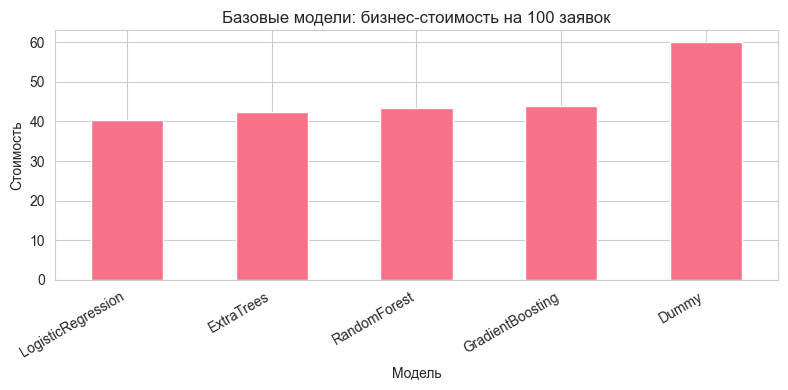

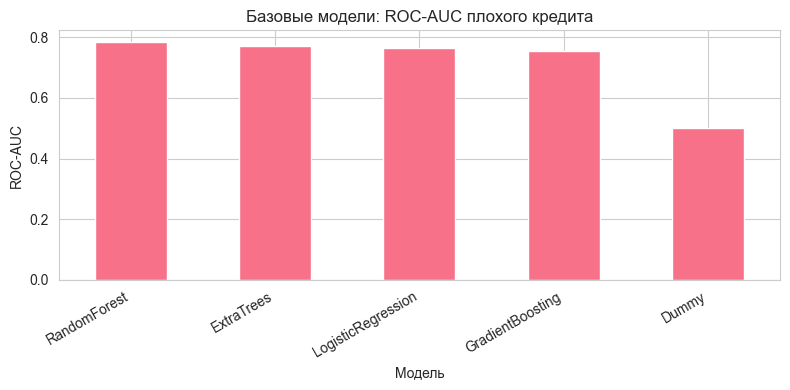

In [52]:
plt.figure(figsize=(8, 4))
base_ranking['business_cost_per_100'].sort_values().plot(kind='bar')
plt.title('Базовые модели: бизнес-стоимость на 100 заявок')
plt.xlabel('Модель')
plt.ylabel('Стоимость')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 4))
base_ranking['roc_auc_bad'].sort_values(ascending=False).plot(kind='bar')
plt.title('Базовые модели: ROC-AUC плохого кредита')
plt.xlabel('Модель')
plt.ylabel('ROC-AUC')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

### 12. Подбор гиперпараметров

Настраиваются три содержательно разных кандидата:

- Logistic Regression — интерпретируемая линейная модель;
- Random Forest — устойчивый ансамбль деревьев;
- Extra Trees — ансамбль с более сильной рандомизацией.

Гиперпараметры подбираются по ROC-AUC. Эта метрика оценивает качество ранжирования вероятностей и не привязана к порогу `0.5`. Бизнес-порог выбирается отдельно по out-of-fold вероятностям.

In [ ]:
tuning_models = {
    'LogisticRegression': LogisticRegression(
        max_iter=3000,
        random_state=RANDOM_STATE,
    ),
    'RandomForest': RandomForestClassifier(
        n_estimators=120,
        random_state=RANDOM_STATE,
        n_jobs=1,
    ),
    'ExtraTrees': ExtraTreesClassifier(
        n_estimators=120,
        random_state=RANDOM_STATE,
        n_jobs=1,
    ),
}

parameter_grids = {
    'LogisticRegression': {
        'model__C': [0.03, 0.1, 0.3],
        'model__class_weight': [None, {0: 1.5, 1: 1}],
    },
    'RandomForest': {
        'model__max_depth': [None, 8, 15],
        'model__min_samples_leaf': [2, 5],
        'model__max_features': ['sqrt'],
        'model__class_weight': ['balanced_subsample'],
    },
    'ExtraTrees': {
        'model__max_depth': [None, 8],
        'model__min_samples_leaf': [2, 5],
        'model__max_features': ['sqrt'],
        'model__class_weight': ['balanced'],
    },
}

search_objects = {}
best_estimators = {}
search_rows = []

for model_name, model in tuning_models.items():
    pipeline = Pipeline([
        ('preprocessor', clone(preprocessor)),
        ('model', clone(model)),
    ])

    search = GridSearchCV(
        estimator=pipeline,
        param_grid=parameter_grids[model_name],
        scoring='roc_auc',
        cv=cv,
        n_jobs=1,
        refit=True,
        return_train_score=True,
    )
    search.fit(X, y)

    search_objects[model_name] = search
    best_estimators[model_name] = search.best_estimator_
    search_rows.append({
        'model': model_name,
        'best_cv_roc_auc': search.best_score_,
        'best_params': search.best_params_,
    })

search_summary = pd.DataFrame(search_rows).sort_values(
    'best_cv_roc_auc', ascending=False
)
pd.set_option('display.max_colwidth', 200)
pd.set_option('display.width', 1000)

display(search_summary)

### 13. Out-of-fold вероятности и подбор порога

In [54]:
def build_threshold_table(
    y_true,
    probability_bad,
    bad_approval_cost=BAD_APPROVAL_COST,
    good_rejection_cost=GOOD_REJECTION_COST,
):
    rows = []

    for threshold in np.arange(0.05, 0.951, 0.01):
        # Метки сохраняются: 0 = bad, 1 = good.
        prediction = np.where(
            probability_bad >= threshold,
            BAD_LABEL,
            GOOD_LABEL,
        )

        metrics = calculate_metrics(
            y_true,
            prediction,
            probability_bad,
            bad_approval_cost=bad_approval_cost,
            good_rejection_cost=good_rejection_cost,
        )
        metrics['threshold_bad'] = round(float(threshold), 2)
        rows.append(metrics)

    return pd.DataFrame(rows)


def select_best_threshold(threshold_table):
    return (
        threshold_table
        .sort_values(
            ['business_cost_per_100', 'bad_approved', 'total_errors', 'recall_bad'],
            ascending=[True, True, True, False],
        )
        .iloc[0]
    )


tuned_candidate_rows = []
oof_probabilities = {}
threshold_tables = {}

for model_name, estimator in best_estimators.items():
    oof_proba = cross_val_predict(
        estimator,
        X,
        y,
        cv=cv,
        method='predict_proba',
        n_jobs=1,
    )

    # У sklearn классы для бинарной классификации упорядочены как [0, 1].
    probability_bad = oof_proba[:, 0]
    oof_probabilities[model_name] = probability_bad

    table = build_threshold_table(y, probability_bad)
    threshold_tables[model_name] = table
    best_row = select_best_threshold(table)

    tuned_candidate_rows.append({
        'model': model_name,
        'threshold_bad': best_row['threshold_bad'],
        'business_cost_per_100': best_row['business_cost_per_100'],
        'bad_approved': int(best_row['bad_approved']),
        'good_rejected': int(best_row['good_rejected']),
        'total_errors': int(best_row['total_errors']),
        'accuracy': best_row['accuracy'],
        'balanced_accuracy': best_row['balanced_accuracy'],
        'precision_bad': best_row['precision_bad'],
        'recall_bad': best_row['recall_bad'],
        'f1_bad': best_row['f1_bad'],
        'roc_auc_bad': best_row['roc_auc_bad'],
        'pr_auc_bad': best_row['pr_auc_bad'],
        'approval_rate': best_row['approval_rate'],
        'bad_rate_among_approved': best_row['bad_rate_among_approved'],
    })

candidate_comparison = (
    pd.DataFrame(tuned_candidate_rows)
    .sort_values(
        ['business_cost_per_100', 'bad_approved', 'roc_auc_bad'],
        ascending=[True, True, False],
    )
    .reset_index(drop=True)
)

display(candidate_comparison)

,model,threshold_bad,business_cost_per_100,bad_approved,good_rejected,total_errors,accuracy,balanced_accuracy,precision_bad,recall_bad,f1_bad,roc_auc_bad,pr_auc_bad,approval_rate,bad_rate_among_approved
0,RandomForest,0.47,32.133333,64,113,177,0.764000,0.750159,0.587591,0.715556,0.645291,0.792102,0.600103,0.634667,0.134454
1,ExtraTrees,0.50,34.933333,61,140,201,0.732000,0.731111,0.539474,0.728889,0.620038,0.781105,0.593807,0.594667,0.136771
2,LogisticRegression,0.29,36.533333,48,178,226,0.698667,0.723810,0.498592,0.786667,0.610345,0.774713,0.580697,0.526667,0.121519


Порог применяется к вероятности плохого кредита: если `P(bad) >= threshold_bad`, модель выдаёт класс `0`; иначе — класс `1`. Целевая переменная при этом не перекодируется.

In [55]:
selected_model_name = candidate_comparison.loc[0, 'model']
best_threshold = float(candidate_comparison.loc[0, 'threshold_bad'])
selected_estimator = best_estimators[selected_model_name]
selected_probability_bad = oof_probabilities[selected_model_name]
selected_threshold_table = threshold_tables[selected_model_name]

oof_prediction = np.where(
    selected_probability_bad >= best_threshold,
    BAD_LABEL,
    GOOD_LABEL,
)

print(f'Выбранная модель: {selected_model_name}')
print(f'Выбранный порог P(bad): {best_threshold:.2f}')
print(
    f'Вес ошибок: bad approved = {BAD_APPROVAL_COST}, '
    f'good rejected = {GOOD_REJECTION_COST}'
)

Выбранная модель: RandomForest
Выбранный порог P(bad): 0.47
Вес ошибок: bad approved = 2, good rejected = 1


### 14. Анализ чувствительности к стоимости ошибок

In [56]:
sensitivity_rows = []

for bad_cost in [1, 2, 5]:
    table = build_threshold_table(
        y,
        selected_probability_bad,
        bad_approval_cost=bad_cost,
        good_rejection_cost=1,
    )
    row = select_best_threshold(table)
    sensitivity_rows.append({
        'bad_approval_cost': bad_cost,
        'good_rejection_cost': 1,
        'threshold_bad': row['threshold_bad'],
        'bad_approved': int(row['bad_approved']),
        'good_rejected': int(row['good_rejected']),
        'total_errors': int(row['total_errors']),
        'business_cost_per_100': row['business_cost_per_100'],
        'approval_rate': row['approval_rate'],
        'bad_rate_among_approved': row['bad_rate_among_approved'],
    })

sensitivity_table = pd.DataFrame(sensitivity_rows)
display(sensitivity_table)

,bad_approval_cost,good_rejection_cost,threshold_bad,bad_approved,good_rejected,total_errors,business_cost_per_100,approval_rate,bad_rate_among_approved
0,1,1,0.52,92,83,175,23.333333,0.712000,0.172285
1,2,1,0.47,64,113,177,32.133333,0.634667,0.134454
2,5,1,0.35,32,234,266,52.533333,0.430667,0.099071


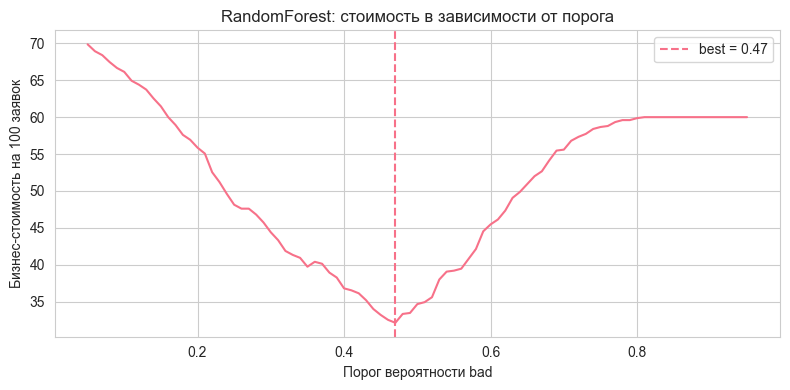

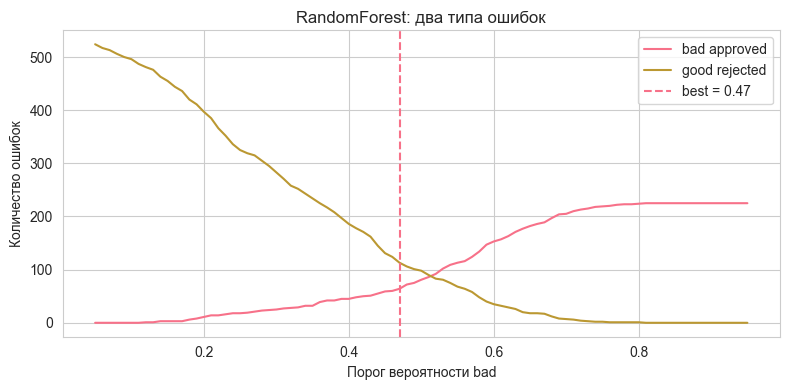

In [57]:
plt.figure(figsize=(8, 4))
plt.plot(
    selected_threshold_table['threshold_bad'],
    selected_threshold_table['business_cost_per_100'],
)
plt.axvline(best_threshold, linestyle='--', label=f'best = {best_threshold:.2f}')
plt.title(f'{selected_model_name}: стоимость в зависимости от порога')
plt.xlabel('Порог вероятности bad')
plt.ylabel('Бизнес-стоимость на 100 заявок')
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(
    selected_threshold_table['threshold_bad'],
    selected_threshold_table['bad_approved'],
    label='bad approved',
)
plt.plot(
    selected_threshold_table['threshold_bad'],
    selected_threshold_table['good_rejected'],
    label='good rejected',
)
plt.axvline(best_threshold, linestyle='--', label=f'best = {best_threshold:.2f}')
plt.title(f'{selected_model_name}: два типа ошибок')
plt.xlabel('Порог вероятности bad')
plt.ylabel('Количество ошибок')
plt.legend()
plt.tight_layout()
plt.show()

### 15. Итоговая OOF-оценка выбранной модели

In [58]:
selected_metrics = calculate_metrics(
    y,
    oof_prediction,
    selected_probability_bad,
)

selected_metrics_table = pd.DataFrame(
    {'value': selected_metrics}
)
display(selected_metrics_table)

print(classification_report(
    y,
    oof_prediction,
    labels=[BAD_LABEL, GOOD_LABEL],
    target_names=['bad (0)', 'good (1)'],
    digits=4,
    zero_division=0,
))

,value
accuracy,0.764000
balanced_accuracy,0.750159
precision_bad,0.587591
recall_bad,0.715556
f1_bad,0.645291
roc_auc_bad,0.792102
pr_auc_bad,0.600103
correctly_rejected_bad,161.000000
bad_approved,64.000000
good_rejected,113.000000


              precision    recall  f1-score   support

     bad (0)     0.5876    0.7156    0.6453       225
    good (1)     0.8655    0.7848    0.8232       525

    accuracy                         0.7640       750
   macro avg     0.7266    0.7502    0.7342       750
weighted avg     0.7822    0.7640    0.7698       750



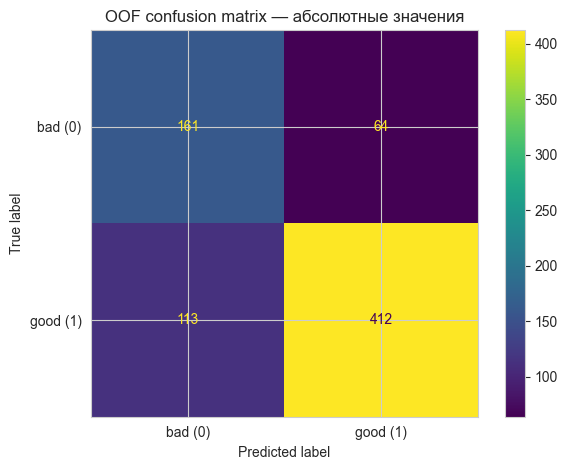

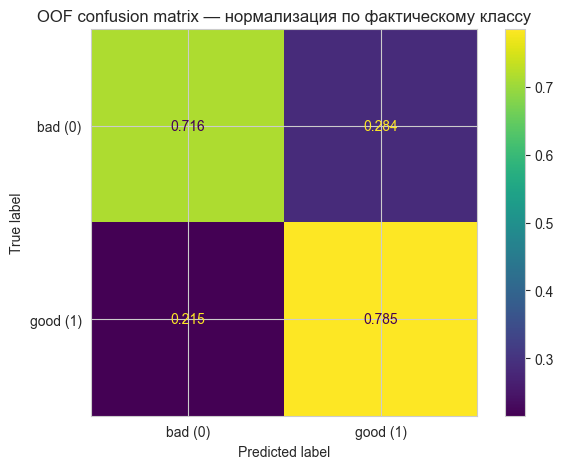

In [59]:
cm_absolute = confusion_matrix(
    y, oof_prediction, labels=[BAD_LABEL, GOOD_LABEL]
)
ConfusionMatrixDisplay(
    confusion_matrix=cm_absolute,
    display_labels=['bad (0)', 'good (1)'],
).plot(values_format='d')
plt.title('OOF confusion matrix — абсолютные значения')
plt.tight_layout()
plt.show()

cm_normalized = confusion_matrix(
    y, oof_prediction, labels=[BAD_LABEL, GOOD_LABEL], normalize='true'
)
ConfusionMatrixDisplay(
    confusion_matrix=cm_normalized,
    display_labels=['bad (0)', 'good (1)'],
).plot(values_format='.3f')
plt.title('OOF confusion matrix — нормализация по фактическому классу')
plt.tight_layout()
plt.show()

### 16. Интерпретация признаков

,feature,importance_mean,importance_std
0,status,0.066984,0.042555
2,credit_history,0.024127,0.020263
1,duration,0.023810,0.016933
5,savings,0.022698,0.009230
4,amount,0.020159,0.023036
12,age,0.015714,0.018021
14,housing,0.012222,0.007614
18,telephone,0.012063,0.006552
15,number_credits,0.012063,0.008642
6,employment_duration,0.010794,0.010134


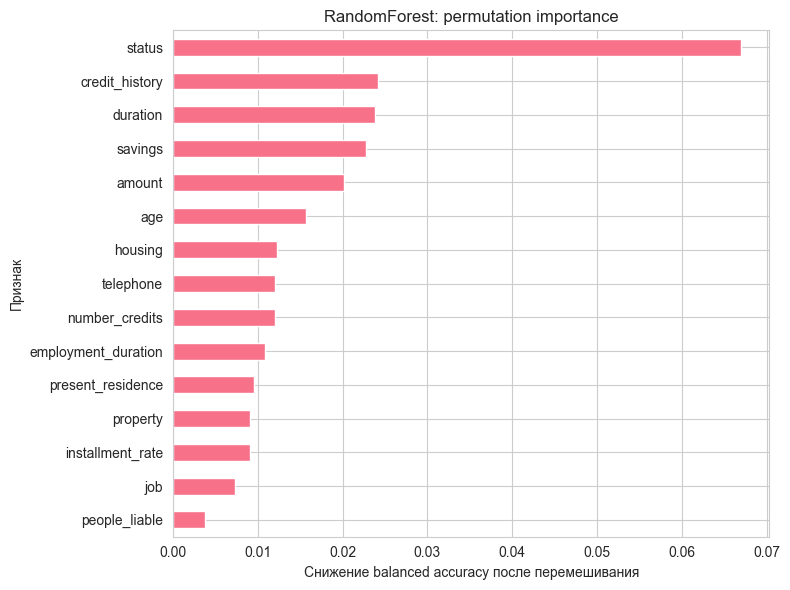

In [60]:
# Для интерпретации используется один фиксированный validation-fold.
# Важность вычисляется на данных, не участвовавших в обучении этой копии модели.
interpret_train_idx, interpret_valid_idx = next(cv.split(X, y))

interpret_estimator = clone(selected_estimator)
interpret_estimator.fit(X.iloc[interpret_train_idx], y.iloc[interpret_train_idx])

importance_result = permutation_importance(
    interpret_estimator,
    X.iloc[interpret_valid_idx],
    y.iloc[interpret_valid_idx],
    scoring='balanced_accuracy',
    n_repeats=10,
    random_state=RANDOM_STATE,
    n_jobs=1,
)

importance_table = (
    pd.DataFrame({
        'feature': X.columns,
        'importance_mean': importance_result.importances_mean,
        'importance_std': importance_result.importances_std,
    })
    .sort_values('importance_mean', ascending=False)
)

display(importance_table)

plt.figure(figsize=(8, 6))
(
    importance_table.head(15)
    .sort_values('importance_mean')
    .set_index('feature')['importance_mean']
    .plot(kind='barh')
)
plt.title(f'{selected_model_name}: permutation importance')
plt.xlabel('Снижение balanced accuracy после перемешивания')
plt.ylabel('Признак')
plt.tight_layout()
plt.show()

## Область работы 3 — финальное обучение и внешний test

Загружаем тестовые данные. Модель, её гиперпараметры и порог уже выбраны по train.

In [ ]:
path_test = Path('test_3dz.csv')

if not path_test.exists():
    raise FileNotFoundError(
        'Файл test_3dz.xls не найден. Поместите его в одну папку с ноутбуком.'
    )

test_df = pd.read_csv(path_test)

if TARGET in test_df.columns:
    raise ValueError('Во внешнем test не должно быть целевой переменной.')

if list(test_df.columns) != list(X.columns):
    missing_in_test = sorted(set(X.columns) - set(test_df.columns))
    extra_in_test = sorted(set(test_df.columns) - set(X.columns))
    raise ValueError(
        f'Наборы признаков не совпадают. '
        f'Нет в test: {missing_in_test}; лишние в test: {extra_in_test}'
    )

print(f'Размер внешнего test: {test_df.shape}')
display(test_df.head())

Размер внешнего test: (250, 20)


,status,duration,credit_history,purpose,amount,savings,employment_duration,installment_rate,personal_status_sex,other_debtors,present_residence,property,age,other_installment_plans,housing,number_credits,job,people_liable,telephone,foreign_worker
0,4,9,4,3,3074,5,3,1,3,1,2,1,33,3,2,2,3,1,1,2
1,2,12,2,9,1037,2,4,3,3,1,4,1,39,3,2,1,2,2,1,2
2,4,27,4,2,4526,4,2,4,3,1,2,1,32,2,2,2,2,1,2,2
3,1,21,4,0,1602,1,5,4,4,1,3,3,30,3,2,2,3,2,2,2
4,1,12,1,0,697,1,2,4,3,1,2,3,46,1,2,2,3,2,2,2


In [ ]:
# После выбора методологии модель обучается на всех 750 объектах train.
final_model = clone(selected_estimator)
final_model.fit(X, y)

final_probabilities = final_model.predict_proba(test_df)
final_classes = final_model.named_steps['model'].classes_
bad_index = int(np.where(final_classes == BAD_LABEL)[0][0])
good_index = int(np.where(final_classes == GOOD_LABEL)[0][0])

probability_bad_test = final_probabilities[:, bad_index]
probability_good_test = final_probabilities[:, good_index]

final_prediction = np.where(
    probability_bad_test >= best_threshold,
    BAD_LABEL,
    GOOD_LABEL,
).astype(int)

submission = pd.DataFrame({
    TARGET: final_prediction,
})

prediction_audit = pd.DataFrame({
    'probability_bad': probability_bad_test,
    'probability_good': probability_good_test,
    TARGET: final_prediction,
})

submission_path = Path('credit_risk_predictions.csv')
audit_path = Path('credit_risk_predictions_with_probabilities.csv')
model_path = Path('credit_risk_model.joblib')
config_path = Path('credit_risk_model_config.json')

submission.to_csv(submission_path, index=False)
prediction_audit.to_csv(audit_path, index=False)
joblib.dump(final_model, model_path)

config = {
    'selected_model': selected_model_name,
    'threshold_bad': best_threshold,
    'bad_label': BAD_LABEL,
    'good_label': GOOD_LABEL,
    'bad_approval_cost': BAD_APPROVAL_COST,
    'good_rejection_cost': GOOD_REJECTION_COST,
    'best_params': search_objects[selected_model_name].best_params_,
    'oof_metrics': {
        key: float(value) if isinstance(value, (float, np.floating)) else int(value)
        for key, value in selected_metrics.items()
    },
}

with config_path.open('w', encoding='utf-8') as file:
    json.dump(config, file, ensure_ascii=False, indent=2)

print(f'Сохранено: {submission_path}')
print(f'Сохранено: {audit_path}')
print(f'Сохранено: {model_path}')
print(f'Сохранено: {config_path}')
display(submission.head())

Сохранено: credit_risk_predictions.csv
Сохранено: credit_risk_predictions_with_probabilities.csv
Сохранено: credit_risk_model.joblib
Сохранено: credit_risk_model_config.json


,credit_risk
0,1
1,1
2,1
3,0
4,0


,class_name,count,share_%
0,bad,83,33.2
1,good,167,66.8


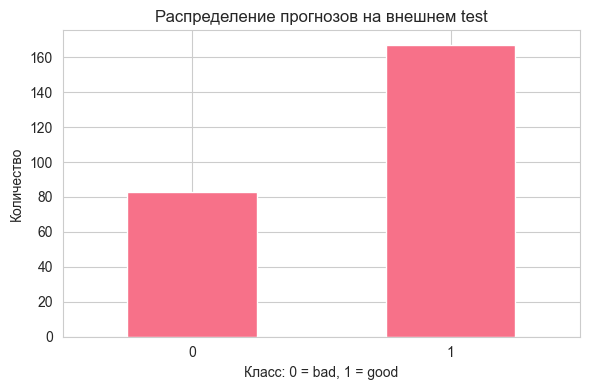

In [ ]:
prediction_distribution = pd.DataFrame({
    'class_name': ['bad', 'good'],
    'count': [
        int((final_prediction == BAD_LABEL).sum()),
        int((final_prediction == GOOD_LABEL).sum()),
    ],
    'share_%': [
        round((final_prediction == BAD_LABEL).mean() * 100, 2),
        round((final_prediction == GOOD_LABEL).mean() * 100, 2),
    ],
}, index=[BAD_LABEL, GOOD_LABEL])

display(prediction_distribution)

plt.figure(figsize=(6, 4))
prediction_distribution['count'].plot(kind='bar')
plt.title('Распределение прогнозов на внешнем test')
plt.xlabel('Класс: 0 = bad, 1 = good')
plt.ylabel('Количество')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()